## Compare Bacformer Large vs ANI vs Panaroo clustering results on E. coli dataset

In [41]:
from pathlib import Path
import pandas as pd
import scanpy as sc
import numpy as np
import anndata

from scipy import sparse
from tqdm import tqdm
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


# leiden resolutiosn to do clustering on
RESOLUTIONS = [0.05, 0.1, 0.2, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]
K_NEIGHBORS = 15

### Read and process ANI data

In [11]:

def read_fastani_matrix(path):
    path = Path(path)

    with path.open() as f:
        n = int(f.readline().strip())

        genome_paths = []
        ani = np.full((n, n), np.nan, dtype=np.float32)
        np.fill_diagonal(ani, 100.0)

        for i, line in enumerate(f):
            fields = line.rstrip("\n").split("\t")
            genome_paths.append(fields[0])

            for j, value in enumerate(fields[1:]):
                if value and value != "NA":
                    value = float(value)
                    ani[i, j] = value
                    ani[j, i] = value

    genome_ids = [Path(fp).stem for fp in genome_paths]
    return pd.DataFrame(ani, index=genome_ids, columns=genome_ids)

ani_df = read_fastani_matrix("/Users/maciejwiatrak/Downloads/ecoli_fastani.out.matrix")

distance_matrix = 1 - (ani_df.to_numpy(dtype=np.float32) / 100)
distance_matrix[~np.isfinite(distance_matrix)] = 1.0
np.fill_diagonal(distance_matrix, 0.0)

def build_knn_graph(distance_matrix, k_neighbors=15):
    n = distance_matrix.shape[0]
    k = min(k_neighbors, n - 1)

    distances = distance_matrix.copy()
    np.fill_diagonal(distances, np.inf)

    neighbor_idx = np.argpartition(distances, kth=k - 1, axis=1)[:, :k]

    rows = np.repeat(np.arange(n), k)
    cols = neighbor_idx.ravel()
    vals = distances[rows, cols]

    keep = np.isfinite(vals)
    rows, cols, vals = rows[keep], cols[keep], vals[keep]

    weights = np.maximum(1.0 - vals, 1e-6)
    graph = sparse.csr_matrix((weights, (rows, cols)), shape=(n, n))

    return graph.maximum(graph.T)

connectivities = build_knn_graph(distance_matrix, k_neighbors=K_NEIGHBORS)

adata = anndata.AnnData(X=np.zeros((len(ani_df), 1), dtype=np.float32))
adata.obs_names = ani_df.index.astype(str)

for res in RESOLUTIONS:
    key = f"leiden_{str(res)}"
    sc.tl.leiden(
        adata,
        resolution=res,
        adjacency=connectivities,
        key_added=key,
    )

ani_df = pd.DataFrame(index=ani_df.index)
ani_df.index.name = "genome_name"

for res in tqdm(RESOLUTIONS):
    key = f"leiden_{str(res)}"
    ani_df[key] = adata.obs[key].astype(str).to_numpy()

ani_df = ani_df.reset_index().sort_values("genome_name")

/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/2392277664.py:58: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(
/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/2392277664.py:58: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.

### Read Bacformer Large clustering results

In [30]:
# Bacformer Large
# load the embeddings
bac_large_df = pd.read_parquet("/Users/maciejwiatrak/Downloads/ecoli_embeds_combined.parquet").sort_values("genome_id").reset_index(drop=True).rename(columns={"genome_id": "genome_name"})

### Read Panaroo data

In [31]:
# Panaroo
panaroo_ecoli_df = pd.read_csv("/Users/maciejwiatrak/Downloads/gene_presence_absence (3).Rtab", sep="\t")

panaroo_ecoli_df = panaroo_ecoli_df.set_index("Gene").transpose()
# sort by index to ensure same order as bac_large_df
panaroo_ecoli_df = panaroo_ecoli_df.sort_index()

### Subset to genomes present in all datasets

In [ ]:
bac_large_genomes = set(bac_large_df.genome_name.tolist())
panaroo_genomes = set(panaroo_ecoli_df.index.tolist())
ani_genomes = set(ani_df.genome_name.tolist())

overlap_genomes = bac_large_genomes & panaroo_genomes & ani_genomes

bac_large_df = bac_large_df[bac_large_df.genome_name.isin(overlap_genomes)].reset_index(drop=True)
panaroo_ecoli_df = panaroo_ecoli_df[panaroo_ecoli_df.index.isin(overlap_genomes)]
ani_df = ani_df[ani_df.genome_name.isin(overlap_genomes)].reset_index(drop=True)

assert bac_large_df.genome_name.tolist() == panaroo_ecoli_df.index.tolist() == ani_df.genome_name.tolist()

### Do the Leiden clustering for Bacformer Large

In [35]:
adata = sc.AnnData(X=np.stack(bac_large_df.embeddings.values), obs=bac_large_df[['genome_name']])

# compute kNN graph
sc.pp.neighbors(adata, use_rep='X')

for resolution in RESOLUTIONS:
    sc.tl.leiden(adata, resolution=resolution, key_added=f"leiden_{resolution}")
    print(f"Resolution {resolution}: {adata.obs[f'leiden_{resolution}'].nunique()} clusters")

bac_large_clusters_df = adata.obs.copy()

/Users/maciejwiatrak/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/2996514789.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=f"leiden_{resolution}")


Resolution 0.05: 3 clusters


/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/2996514789.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=f"leiden_{resolution}")


Resolution 0.1: 4 clusters


/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/2996514789.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=f"leiden_{resolution}")


...

Resolution 20.0: 147 clusters


/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/2996514789.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=f"leiden_{resolution}")


Resolution 50.0: 318 clusters


/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/2996514789.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=f"leiden_{resolution}")


Resolution 100.0: 592 clusters


### Do the Leiden clustering for Panaroo

In [45]:
# Rows = genomes/strains, columns = binary gene presence/absence features
adata = anndata.AnnData(
    X=panaroo_ecoli_df.values,
    obs=pd.DataFrame(index=panaroo_ecoli_df.index.astype(str)),
)

# Build row-neighborhood graph from the binary matrix
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=50,
)

for resolution in RESOLUTIONS:
    col = f"leiden_{resolution}"
    print(col)
    sc.tl.leiden(
        adata,
        resolution=resolution,
        key_added=col,
    )

panaroo_clusters_df = adata.obs.copy().reset_index().rename(columns={"index": "genome_name"})

leiden_0.05


/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/3222352452.py:18: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


leiden_0.1


/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/3222352452.py:18: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


leiden_0.2


...

/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/3222352452.py:18: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


leiden_50.0


/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/3222352452.py:18: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


leiden_100.0


/var/folders/03/cqvkxcyx19g01v4r4gc8r8dr0000gn/T/ipykernel_42017/3222352452.py:18: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


## Compare Bacformer Large vs ANI vs Panaroo clustering results on E. coli dataset

In [54]:
cluster_cols = [c for c in bac_large_clusters_df.columns if c.startswith("leiden_")]

merged = bac_large_clusters_df.merge(
    panaroo_clusters_df,
    on="genome_name",
    how="inner",
    suffixes=("_bac_large", "_panaroo"),
)

rows = []

for bac_res_col in cluster_cols:
    bac_labels = merged[f"{bac_res_col}_bac_large"].astype(str)

    for panaroo_res_col in cluster_cols:
        panaroo_labels = merged[f"{panaroo_res_col}_panaroo"].astype(str)

        rows.append(
            {
                "bac_resolution": bac_res_col.replace("leiden_", ""),
                "panaroo_resolution": panaroo_res_col.replace("leiden_", ""),
                "n_genomes": len(merged),
                "ari": adjusted_rand_score(panaroo_labels, bac_labels),
                "nmi": normalized_mutual_info_score(panaroo_labels, bac_labels),
                "n_bac_large_clusters": bac_labels.nunique(),
                "n_panaroo_clusters": panaroo_labels.nunique(),
            }
        )

bac_vs_panaroo_df = (
    pd.DataFrame(rows)
    .sort_values("nmi", ascending=False)
    .reset_index(drop=True)
)

print(f"Bacformer vs Panaroo best NMI: {bac_vs_panaroo_df.iloc[0]['nmi']:.4f} at Bacformer resolution {bac_vs_panaroo_df.iloc[0]['bac_resolution']} and Panaroo resolution {bac_vs_panaroo_df.iloc[0]['panaroo_resolution']}")

merged = bac_large_clusters_df.merge(
    ani_df,
    on="genome_name",
    how="inner",
    suffixes=("_bac_large", "_ani"),
)

rows = []

for bac_res_col in cluster_cols:
    bac_labels = merged[f"{bac_res_col}_bac_large"].astype(str)

    for ani_res_col in cluster_cols:
        ani_labels = merged[f"{ani_res_col}_ani"].astype(str)

        rows.append(
            {
                "bac_resolution": bac_res_col.replace("leiden_", ""),
                "panaroo_resolution": ani_res_col.replace("leiden_", ""),
                "n_genomes": len(merged),
                "ari": adjusted_rand_score(ani_labels, bac_labels),
                "nmi": normalized_mutual_info_score(ani_labels, bac_labels),
                "n_bac_large_clusters": bac_labels.nunique(),
                "n_panaroo_clusters": ani_labels.nunique(),
            }
        )

bac_vs_ani_df = (
    pd.DataFrame(rows)
    .sort_values("nmi", ascending=False)
    .reset_index(drop=True)
)

print(f"Bacformer vs ANI best NMI: {bac_vs_ani_df.iloc[0]['nmi']:.4f} at Bacformer resolution {bac_vs_ani_df.iloc[0]['bac_resolution']} and ANI resolution {bac_vs_ani_df.iloc[0]['panaroo_resolution']}")

Bacformer vs Panaroo best NMI: 0.8021 at Bacformer resolution 100.0 and Panaroo resolution 100.0
Bacformer vs ANI best NMI: 0.7968 at Bacformer resolution 100.0 and ANI resolution 100.0


In [55]:
merged = panaroo_clusters_df.merge(
    ani_df,
    on="genome_name",
    how="inner",
    suffixes=("_panaroo", "_ani"),
)

rows = []

for panaroo_res_col in cluster_cols:
    panaroo_labels = merged[f"{panaroo_res_col}_panaroo"].astype(str)

    for ani_res_col in cluster_cols:
        ani_labels = merged[f"{ani_res_col}_ani"].astype(str)

        rows.append(
            {
                "bac_resolution": panaroo_res_col.replace("leiden_", ""),
                "panaroo_resolution": ani_res_col.replace("leiden_", ""),
                "n_genomes": len(merged),
                "ari": adjusted_rand_score(ani_labels, panaroo_labels),
                "nmi": normalized_mutual_info_score(ani_labels, panaroo_labels),
                "n_bac_large_clusters": panaroo_labels.nunique(),
                "n_panaroo_clusters": ani_labels.nunique(),
            }
        )

panaroo_vs_ani_df = (
    pd.DataFrame(rows)
    .sort_values("nmi", ascending=False)
    .reset_index(drop=True)
)

print(f"Panaroo vs ANI best NMI: {panaroo_vs_ani_df.iloc[0]['nmi']:.4f} at Panaroo resolution {panaroo_vs_ani_df.iloc[0]['bac_resolution']} and ANI resolution {panaroo_vs_ani_df.iloc[0]['panaroo_resolution']}")

Panaroo vs ANI best NMI: 0.8138 at Panaroo resolution 100.0 and ANI resolution 100.0


## Do the bootstrapping to get confidence intervals for the NMI scores

,comparison,resolution,n_genomes,nmi,sample_fraction,n_bootstrap,subsample_mean_nmi,ci_low,ci_high
0,Bacformer vs Panaroo,100.0,2479,0.802147,0.8,100,0.823408,0.821297,0.825510
1,Bacformer vs ANI,100.0,2479,0.796786,0.8,100,0.818531,0.816289,0.820511


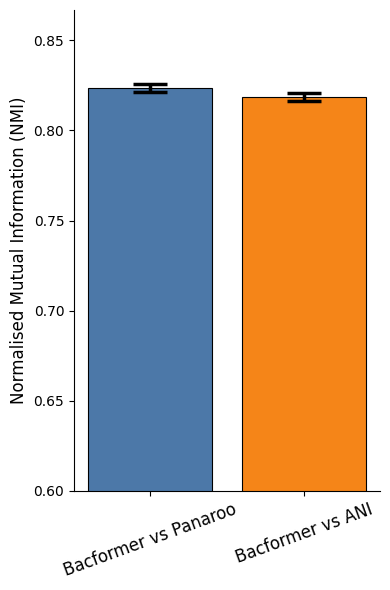

In [70]:
import matplotlib.pyplot as plt


res_col = "leiden_100.0"
n_bootstrap = 100
rng = np.random.default_rng(0)


def bootstrap_nmi(labels_a, labels_b, *, n_bootstrap=100, sample_fraction=0.8, rng=None):
    """Estimate NMI variability by repeatedly subsampling paired genomes."""
    labels_a = np.asarray(labels_a).astype(str)
    labels_b = np.asarray(labels_b).astype(str)

    if labels_a.shape != labels_b.shape:
        raise ValueError("labels_a and labels_b must have the same shape.")

    rng = np.random.default_rng() if rng is None else rng
    n = labels_a.shape[0]
    sample_size = max(2, int(np.floor(sample_fraction * n)))
    scores = np.empty(n_bootstrap, dtype=float)

    for i in range(n_bootstrap):
        sample_idx = rng.choice(n, size=sample_size, replace=False)
        scores[i] = normalized_mutual_info_score(labels_a[sample_idx], labels_b[sample_idx])

    return scores


bac_panaroo_100 = bac_large_clusters_df[["genome_name", res_col]].merge(
    panaroo_clusters_df[["genome_name", res_col]],
    on="genome_name",
    how="inner",
    suffixes=("_bac_large", "_panaroo"),
)

bac_ani_100 = bac_large_clusters_df[["genome_name", res_col]].merge(
    ani_df[["genome_name", res_col]],
    on="genome_name",
    how="inner",
    suffixes=("_bac_large", "_ani"),
)

comparisons = {
    "Bacformer vs Panaroo": (
        bac_panaroo_100[f"{res_col}_bac_large"],
        bac_panaroo_100[f"{res_col}_panaroo"],
        len(bac_panaroo_100),
    ),
    "Bacformer vs ANI": (
        bac_ani_100[f"{res_col}_bac_large"],
        bac_ani_100[f"{res_col}_ani"],
        len(bac_ani_100),
    ),
}

bootstrap_rows = []
bootstrap_scores = {}

for comparison, (bac_labels, other_labels, n_genomes) in comparisons.items():
    point_nmi = normalized_mutual_info_score(other_labels.astype(str), bac_labels.astype(str))
    scores = bootstrap_nmi(
        bac_labels,
        other_labels,
        n_bootstrap=n_bootstrap,
        sample_fraction=0.8,
        rng=rng,
    )
    ci_low, ci_high = np.percentile(scores, [2.5, 97.5])
    bootstrap_scores[comparison] = scores
    bootstrap_rows.append(
        {
            "comparison": comparison,
            "resolution": res_col.replace("leiden_", ""),
            "n_genomes": n_genomes,
            "nmi": point_nmi,
            "sample_fraction": 0.8,
            "n_bootstrap": n_bootstrap,
            "subsample_mean_nmi": scores.mean(),
            "ci_low": ci_low,
            "ci_high": ci_high,
        }
    )

bootstrap_nmi_df = pd.DataFrame(bootstrap_rows)

x = np.arange(len(bootstrap_nmi_df))
y = bootstrap_nmi_df["subsample_mean_nmi"].to_numpy()
yerr = np.vstack(
    [
        np.maximum(y - bootstrap_nmi_df["ci_low"].to_numpy(), 0),
        np.maximum(bootstrap_nmi_df["ci_high"].to_numpy() - y, 0),
    ]
)

fig, ax = plt.subplots(figsize=(4, 6))
ax.bar(
    x,
    y,
    yerr=yerr,
    capsize=12,
    color=["#4C78A8", "#F58518"],
    edgecolor="black",
    linewidth=0.8,
    error_kw={"elinewidth": 2.5, "capthick": 2.5, "ecolor": "black"},
)
ax.set_xticks(x)
ax.set_xticklabels(bootstrap_nmi_df["comparison"], rotation=20, fontsize=12)
ax.set_ylabel("Normalised Mutual Information (NMI)", fontsize=12)
# x.set_title("Leiden resolution 100.0 NMI, 80% genome subsamples")
ax.set_ylim(0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

bootstrap_nmi_df
